# 🤖 Ensemble ML — Flowers Classification
โมเดล: RF + ExtraTrees + SVM + XGBoost + LightGBM → StackingClassifier

In [3]:
import os
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from PIL import Image, ImageEnhance
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv
from skimage.filters import gabor
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

DATASET_PATH = "../dataset1_flower/Flower_Recognition/flowers"
CLASSES = ["daisy", "dandelion", "rose", "sunflower", "tulip"]
IMG_SIZE = (96, 96)
MAX_PER_CLASS = 300
print(f"Libraries loaded | Max per class: {MAX_PER_CLASS}")

Libraries loaded | Max per class: 300


In [4]:
# === IMPROVED FEATURE EXTRACTION ===

def extract_color_histogram(img, bins=64):
    """Color histogram: RGB + HSV"""
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(img[:, :, ch], bins=bins, range=(0, 256))
        feats.extend(hist / (hist.sum() + 1e-7))
    img_hsv = (rgb2hsv(img) * 255).astype(np.uint8)
    for ch in range(3):
        hist, _ = np.histogram(img_hsv[:, :, ch], bins=bins, range=(0, 256))
        feats.extend(hist / (hist.sum() + 1e-7))
    return np.array(feats)

def extract_hog_features(gray):
    """Multi-scale HOG"""
    feat1 = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), feature_vector=True)
    feat2 = hog(gray, orientations=12, pixels_per_cell=(16, 16),
                cells_per_block=(2, 2), feature_vector=True)
    return np.concatenate([feat1, feat2])

def extract_lbp_features(gray):
    """Multi-radius LBP"""
    feats = []
    for radius in [1, 2, 3]:
        n_points = 8 * radius
        lbp = local_binary_pattern(gray, P=n_points, R=radius, method="uniform")
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins))
        feats.extend(hist / (hist.sum() + 1e-7))
    return np.array(feats)

def extract_gabor_features(gray):
    """Gabor texture features"""
    feats = []
    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        for freq in [0.1, 0.2, 0.3]:
            filt_real, filt_imag = gabor(gray, frequency=freq, theta=theta)
            feats.extend([filt_real.mean(), filt_real.std(),
                          filt_imag.mean(), filt_imag.std()])
    return np.array(feats)

def extract_statistical_features(img, gray):
    """Statistical moments ของแต่ละ channel"""
    feats = []
    for ch in range(3):
        ch_data = img[:, :, ch].flatten().astype(float)
        feats.extend([ch_data.mean(), ch_data.std(),
                      float(stats.skew(ch_data)), float(stats.kurtosis(ch_data))])
    g = gray.flatten()
    feats.extend([g.mean(), g.std(), float(stats.skew(g)), float(stats.kurtosis(g))])
    return np.array(feats)

def extract_features(img_array):
    """รวม features ทั้งหมด"""
    img = np.array(Image.fromarray(img_array).resize(IMG_SIZE))
    gray = rgb2gray(img)
    return np.concatenate([
        extract_hog_features(gray),
        extract_color_histogram(img, bins=64),
        extract_lbp_features(gray),
        extract_gabor_features(gray),
        extract_statistical_features(img, gray)
    ])

print("Feature extraction ready")
test_feat = extract_features(np.random.randint(0, 255, (100, 100, 3), dtype=np.uint8))
print(f"Feature dimension: {test_feat.shape[0]}")

Feature extraction ready
Feature dimension: 6058


In [5]:
# === DATA AUGMENTATION + LOADING ===

def augment_image(img_array):
    """สร้าง variants เพื่อเพิ่ม diversity"""
    variants = [img_array]
    img = Image.fromarray(img_array)
    # Horizontal flip
    variants.append(np.array(img.transpose(Image.FLIP_LEFT_RIGHT)))
    # Brightness +/-
    for factor in [1.3, 0.7]:
        variants.append(np.array(ImageEnhance.Brightness(img).enhance(factor)))
    # Contrast +
    variants.append(np.array(ImageEnhance.Contrast(img).enhance(1.4)))
    return variants

X, y = [], []
for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    files = [f for f in os.listdir(folder)
             if f.endswith((".jpg", ".jpeg", ".png"))][:MAX_PER_CLASS]
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            img = np.array(Image.open(fpath).convert("RGB"))
            for variant in augment_image(img):
                X.append(extract_features(variant))
                y.append(cls)
        except:
            pass

X = np.array(X)
print(f"Total samples (with augmentation): {len(X)}, Feature dim: {X.shape[1]}")

Total samples (with augmentation): 7500, Feature dim: 6058


In [8]:
# === PREPROCESSING ===
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# === IMPUTE ===
imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# === SCALE ===
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

# === PCA ===
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print(f"Train: {X_train_pca.shape}, Test: {X_test_pca.shape}")
print(f"PCA: {pca.n_components_} components (จาก {X_train.shape[1]} features)")

Train: (6000, 1090), Test: (1500, 1090)
PCA: 1090 components (จาก 6058 features)


In [9]:
# === IMPROVED MODELS ===

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300, min_samples_split=5, min_samples_leaf=2,
    max_features="sqrt", class_weight="balanced",
    random_state=42, n_jobs=-1
)

# Extra Trees — เพิ่ม diversity
et = ExtraTreesClassifier(
    n_estimators=300, max_features="sqrt",
    class_weight="balanced", random_state=42, n_jobs=-1
)

# SVM — เพิ่ม C จาก 1 → 10
svm = SVC(
    kernel="rbf", C=6, gamma="scale",
    probability=True, class_weight="balanced", random_state=42
)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric="mlogloss", random_state=42, n_jobs=-1
)

# LightGBM — โมเดลใหม่ เร็วและแม่นยำ
lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
)

# === STACKING ENSEMBLE ===
# Stacking: ใช้ meta-learner combine predictions แทน simple voting
estimators_list = [
    ("rf", rf), ("et", et), ("svm", svm), ("xgb", xgb), ("lgbm", lgbm)
]

ensemble = StackingClassifier(
    estimators=estimators_list,
    final_estimator=LogisticRegression(C=1.0, max_iter=5000, random_state=42),
    cv=5,
    stack_method="predict_proba",
    n_jobs=-1
)

print("Training Stacking Ensemble (5 base learners + meta-learner)...")
print("อาจใช้เวลาสักครู่...")
ensemble.fit(X_train_pca, y_train)
print("Training complete!")

Training Stacking Ensemble (5 base learners + meta-learner)...
อาจใช้เวลาสักครู่...
Training complete!


In [10]:
# === EVALUATION ===
y_pred = ensemble.predict(X_test_pca)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.9187 (91.87%)

              precision    recall  f1-score   support

       daisy       0.95      0.92      0.93       300
   dandelion       0.89      0.93      0.91       300
        rose       0.92      0.91      0.91       300
   sunflower       0.92      0.94      0.93       300
       tulip       0.91      0.89      0.90       300

    accuracy                           0.92      1500
   macro avg       0.92      0.92      0.92      1500
weighted avg       0.92      0.92      0.92      1500



Individual model accuracies:
  rf    : 0.8873 (88.73%)
  et    : 0.8740 (87.40%)
  svm   : 0.9193 (91.93%)
  xgb   : 0.8987 (89.87%)
  lgbm  : 0.9093 (90.93%)
  Stacking: 0.9187 (91.87%)  <- Final


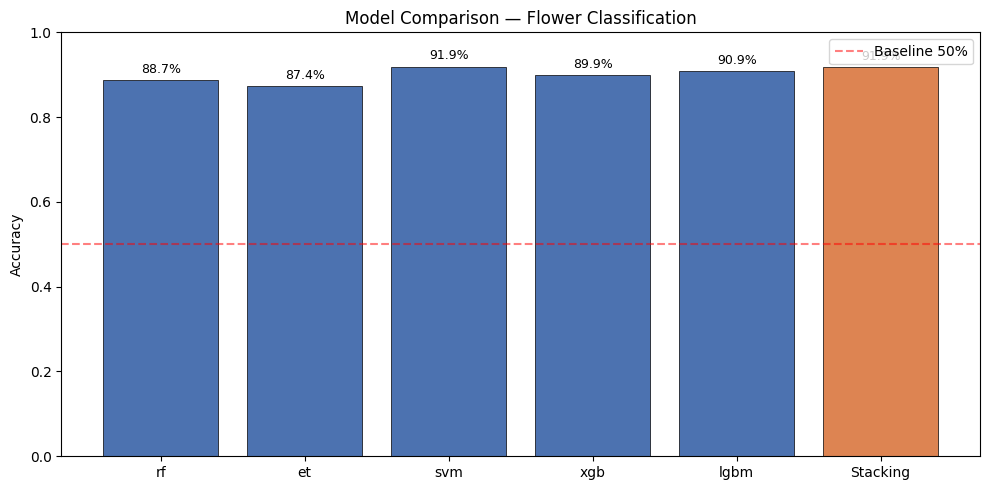

In [11]:
# === COMPARE INDIVIDUAL MODELS VS ENSEMBLE ===
print("Individual model accuracies:")
results = {}
for name, model in estimators_list:
    model.fit(X_train_pca, y_train)
    pred = model.predict(X_test_pca)
    acc_i = accuracy_score(y_test, pred)
    results[name] = acc_i
    print(f"  {name:6s}: {acc_i:.4f} ({acc_i*100:.2f}%)")
results["Stacking"] = acc
print(f"  Stacking: {acc:.4f} ({acc*100:.2f}%)  <- Final")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4C72B0"] * len(estimators_list) + ["#DD8452"]
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Baseline 50%")
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title("Model Comparison — Flower Classification")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("../models/model_comparison.png", dpi=150)
plt.show()

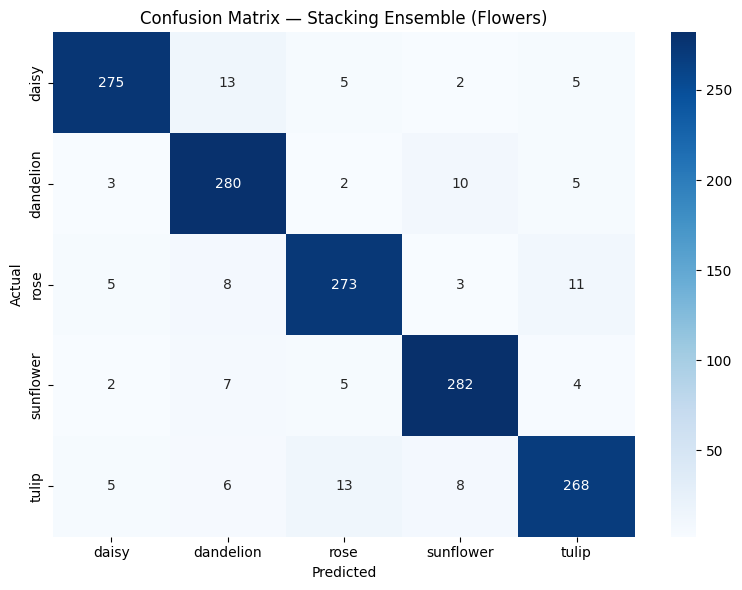

In [12]:
# === CONFUSION MATRIX ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Stacking Ensemble (Flowers)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../models/confusion_matrix_ml.png", dpi=150)
plt.show()

In [13]:
# === SAVE MODEL ===
os.makedirs("../models", exist_ok=True)
joblib.dump({
    "model": ensemble,
    "scaler": scaler,
    "label_encoder": le,
    "pca": pca
}, "../models/ensemble_model.pkl")
print(f"บันทึกโมเดลแล้ว — Final Accuracy: {acc*100:.2f}%")

บันทึกโมเดลแล้ว — Final Accuracy: 91.87%
